# RFM 실습편

RFM을 실습하고, 이를 토대로 인사이트를 얻어보자.

link  https://www.kaggle.com/datasets/thedevastator/online-retail-transaction-data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('C:/Users/USER/Desktop/TIL_new/data_analyst_practice/online_retail.csv')

In [2]:
df.head(10)

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom


데이터의 주요 사항은 다음과 같다.
- invocie number : 송장번호, 하나의 거래 묶음일것이다 라고 볼 수 있다.
- Stock Code, Description : 상품코드와 상품명이다. 구체적인 대분류를 알기는 어렵다.
- Quantity, UnitPrice : 구매 수량 및 개당 가격이다. 달러 단위일 것으로 추정된다.
- Country : 구매 지역(국가)이다.

이번에 풀어볼 문제는 다음과 같다.
- 유저들을 잘 그룹화하여, 유의미하게 분류하여 인사이트를 획득해보자
- 각 그룹별 특성을 파악하여 알맞은 비즈니스 전략을 수립해보자

## 데이터 체크

오류 데이터나 결측치가 있을 수 있으므로 체크한다.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   index        541909 non-null  int64  
 1   InvoiceNo    541909 non-null  object 
 2   StockCode    541909 non-null  object 
 3   Description  540455 non-null  object 
 4   Quantity     541909 non-null  int64  
 5   InvoiceDate  541909 non-null  object 
 6   UnitPrice    541909 non-null  float64
 7   CustomerID   406829 non-null  float64
 8   Country      541909 non-null  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 37.2+ MB


CustomerId가 null인 케이스가 존재한다. 무슨 상황인지 좀 보자

In [4]:
df.loc[df.CustomerID != df.CustomerID]

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,622,536414,22139,NaN,56,12/1/2010 11:52,0.00,NaN,United Kingdom
1443,1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/2010 14:32,2.51,NaN,United Kingdom
1444,1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/2010 14:32,2.51,NaN,United Kingdom
1445,1445,536544,21786,POLKADOT RAIN HAT,4,12/1/2010 14:32,0.85,NaN,United Kingdom
1446,1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/2010 14:32,1.66,NaN,United Kingdom
...,...,...,...,...,...,...,...,...,...
541536,541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,12/9/2011 10:26,4.13,NaN,United Kingdom
541537,541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,12/9/2011 10:26,4.13,NaN,United Kingdom
541538,541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,12/9/2011 10:26,4.96,NaN,United Kingdom
541539,541539,581498,85174,S/4 CACTI CANDLES,1,12/9/2011 10:26,10.79,NaN,United Kingdom


송장의 번호는 존재하나 고객 정보를 확인할 수 없다. 어떤 고객인지 알 수 없으므로 해당 데이터는 drop 처리하다.
상품의 상세 정보는 이번 분석에서는 크게 중요하지 않다. (사실 상품군을 알면 분석하기 좋은데, 의미가 없다)

## 데이터 전처리

RFM을 위해서 고려해야 하는 사항은 다음과 같다.
- 가장 마지막 구매일 : 최종 결제일을 알 수 있다. (R)
- 총 구매 종류 수 : 전체적으로 산 상품의 종류 수를 알 수 있다. (F)
- 총 구매 상품 개수 : 그래서 총 몇 개의 상품을 샀는지도 참고할 수 있다. (F)
- 총 Invoice 개수 : 그래서 몇 묶음(몇 번의 "주문")을 샀는지 알 수 있다. (F)
- 총 가격합 : 그래서 Quantity * Price의 합으로 몇달러의 매출을 냈는지 알 수 있다. (M)

이렇게 고려하는 이유는 상품의 구매 빈도라는 것에 대해 다양하게 해석할 수 있다.
- 구매 횟수가 적더라도 상대적으로 다량을 한번에 반복해서 구매할 수 있다.
- 구매 종류도 적고 횟수도 적더라도 애초에 양을 많이 구매할 수 있다.
- 구매 수량이나 종류가 적더라도 구매 자체를 반복적으로 꾸준히 할 수 있다.
- 딱 1회만 다량으로 살 수도 있다..

이러한 다양한 문제 상황이 존재하기에 F를 3가지로 나눠서 같이 고려해주는 것이 더 합리적일 것이다.
이거 sql이 더 편하니까, data를 sql로 뽑아보자

In [5]:
# 그 전에 nan 정도는 버리자.
df = df.loc[df.CustomerID == df.CustomerID]

In [6]:
'''
import sqlite3
import pandas as pd
# 없을때는 테이블이 생성되고, 있을때는 불러온다
#con = sqlite3.connect("customer_retail.db")
#최초로 테이블을 create안하고 이미 있는 파일을 load 시킬려면 이렇게 한다.
#다만 이미 생성된 이후로는 error걸리므로 최초 실행 이후로는 주석 필수!
#df.to_sql('customer_retail', con)
#cur = con.cursor()
'''

In [7]:
'''
script="""
SELECT
    CustomerID,
    count(*),
    count(distinct InvoiceNo),
    sum(Quantity),
    sum(Quantity * UnitPrice),
    max(substr(InvoiceDate, 1, 9))
FROM customer_retail
GROUP BY CustomerID
LIMIT 5
"""

cur.execute(script)
result = cur.fetchall()
print(result)
'''

[(12346.0, 2, 2, 0, 0.0, '1/18/2011'), (12347.0, 182, 7, 2458, 4309.999999999997, '8/2/2011 '), (12348.0, 31, 4, 2341, 1797.24, '9/25/2011'), (12349.0, 73, 1, 631, 1757.55, '11/21/201'), (12350.0, 17, 1, 197, 334.40000000000003, '2/2/2011 ')]


오잉 결과가 이상하다? 매출액이나 구매 수량이 0일 수 없다. 그 이유를 확인해보자

In [8]:
df.loc[df.CustomerID == 12346]

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
61619,61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1/18/2011 10:01,1.04,12346.0,United Kingdom
61624,61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,1/18/2011 10:17,1.04,12346.0,United Kingdom


InvoiceNo가 C를 제외하고 같았으면 좋을려만 다르다.

In [9]:
df.loc[df.Quantity < 0]

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...,...
540449,540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/2011 9:57,0.83,14397.0,United Kingdom
541541,541541,C581499,M,Manual,-1,12/9/2011 10:28,224.69,15498.0,United Kingdom
541715,541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/2011 11:57,10.95,15311.0,United Kingdom
541716,541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/2011 11:58,1.25,17315.0,United Kingdom


또, 다른 상황이 존재한다.. 이에 대한 추가 전처리가 필요하다

## 추가 전처리

즉, 여기서는 음의 값을 가지는 경우는 할인이거나 환불 등의 상황일 것이므로 전부 제거해줘야 한다.

In [10]:
df = df.reset_index(drop = True)
df

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...,...
406824,541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
406825,541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
406826,541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
406827,541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


다음과 같이 인덱스를 리셋하였다. 이제 이를 바탕으로 전처리를 진행한다.
- 양이 음수일 경우 제거할 인덱스 번호에 넣는다.
- 그리고 해당 인덱스에서 상세명, 양 * -1, Unit price, Customer가 동일한 케이스를 찾는다. 그 건도 제거 인덱스에 넣는다.
- 제거 인덱스는 모두 제거한다.

In [16]:
'''
del_indx = []
for i in range(len(df)):
    cur_row = df.loc[i]
    if cur_row['Quantity'] < 0:
        del_indx.append(cur_row['index'])
        cur_des = cur_row['Description']
        cur_quan = cur_row['Quantity'] * -1
        cur_id = cur_row['CustomerID']
        del_df = df.loc[(df.Description == cur_des) & (df.Quantity == cur_quan) & (df.CustomerID == cur_id)]
        if len(del_df) > 0:
            cur_del_idx = list(del_df['index'])[0]
            del_indx.append(cur_del_idx)
'''

이제 해당 번호를 지운 뒤에, 다시 데이터베이스에 저장해야 한다...

In [28]:
del_indx = sorted(del_indx)

In [30]:
len(del_indx)

12149

In [31]:
'''
# 지워야할 index 체크가 너무 많아서 어렵다. 이진탐색으로 빠르게 끝내게 만들어주자.
# 안그러면 사십만 * 만개이어서 얼마나 걸릴지 모른다.
def binary_check_indx(x):
    start = 0
    end = len(del_indx) - 1
    
    while start <= end:
        mid = (start + end) // 2
        
        # 그 값일 경우 제외해야 한다.
        if x == del_indx[mid]:
            return False
        # 찾아야할 인덱스가 적을 경우
        elif del_indx[mid] > x:
            end = mid - 1
        else:
            start = mid + 1
    return True

df_condi = df['index'].apply(lambda x : binary_check_indx(x))
df = df.loc[df_condi]
'''

In [32]:
df

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...,...
406824,541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
406825,541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
406826,541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
406827,541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [2]:
df_cut = pd.read_csv('C:/Users/USER/Desktop/TIL_new/data_analyst_practice/online_retail_sub.csv')

In [3]:
df_cut

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...,...
394861,541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
394862,541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
394863,541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
394864,541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


문제는 날짜 형식도 제각각이다... 진짜...맞는 형식이 없어서 직접 변환해야 한다.

In [21]:
def get_date(x):
    x = str(x)
    x_list = list(x.split('/'))
    x_year = x_list[2][0:4]
    x_month = str(x_list[0])
    if len(x_month) == 1:
        x_month = '0' + x_month
    x_day = str(x_list[1])
    if len(x_day) == 1:
        x_day = '0' + x_day
    return x_year + '-' + x_month + '-' + x_day
    

In [22]:
df_cut['InvoiceDate'] = df_cut.InvoiceDate.apply(lambda x : get_date(str(x)))

In [26]:
import sqlite3
# 없을때는 테이블이 생성되고, 있을때는 불러온다
'''
con = sqlite3.connect("customer_retail.db")
#최초로 테이블을 create안하고 이미 있는 파일을 load 시킬려면 이렇게 한다.
#다만 이미 생성된 이후로는 error걸리므로 최초 실행 이후로는 주석 필수!
df_cut.to_sql('customer_retail', con)
cur = con.cursor()
'''

script="""
SELECT
    CustomerID,
    count(*),
    count(distinct InvoiceNo),
    sum(Quantity),
    Round(sum(Quantity * UnitPrice), 2),
    max(substr(InvoiceDate, 1, 10))
FROM customer_retail
GROUP BY CustomerID
"""

cur.execute(script)
result = cur.fetchall()


이 result를 이제 저장해두자

In [33]:
pd.DataFrame(data = result, columns = ['id', 'cnt_prod', 'cnt_pay', 'cnt_quant', 'total_rev', 'last_buy_date'])

,id,cnt_prod,cnt_pay,cnt_quant,total_rev,last_buy_date
0,12347.0,182,7,2458,4310.00,2011-12-07
1,12348.0,31,4,2341,1797.24,2011-09-25
2,12349.0,73,1,631,1757.55,2011-11-21
3,12350.0,17,1,197,334.40,2011-02-02
4,12352.0,77,8,472,2009.21,2011-11-03
...,...,...,...,...,...,...
4321,18280.0,10,1,45,180.60,2011-03-07
4322,18281.0,7,1,54,80.82,2011-06-12
4323,18282.0,12,2,103,178.05,2011-12-02
4324,18283.0,756,16,1397,2094.88,2011-12-06


이렇게 총 4325명의 고객의 데이터를 획득할 수 있다. 이를 저장하자. 제발.

In [ ]:
customer_df['id'] = customer_df.id.apply(lambda x : int(x))
customer_df = pd.DataFrame(data = result, columns = ['id', 'cnt_prod', 'cnt_pay', 'cnt_quant', 'total_rev', 'last_buy_date'])
customer_df.to_csv('C:/Users/USER/Desktop/TIL_new/data_analyst_practice/online_retail_customer.csv'. index = False)

## RFM 분석

전처리가 끝나, 이제 RFM 분석이 가능해졌다...

In [3]:
customer_df= pd.read_csv('C:/Users/USER/Desktop/TIL_new/data_analyst_practice/online_retail_customer.csv')
customer_df

,id,cnt_prod,cnt_pay,cnt_quant,total_rev,last_buy_date
0,12347,182,7,2458,4310.00,2011-12-07
1,12348,31,4,2341,1797.24,2011-09-25
2,12349,73,1,631,1757.55,2011-11-21
3,12350,17,1,197,334.40,2011-02-02
4,12352,77,8,472,2009.21,2011-11-03
...,...,...,...,...,...,...
4321,18280,10,1,45,180.60,2011-03-07
4322,18281,7,1,54,80.82,2011-06-12
4323,18282,12,2,103,178.05,2011-12-02
4324,18283,756,16,1397,2094.88,2011-12-06


그러면 이제 값의 범위를 살펴보자.

In [4]:
customer_df['id'] = customer_df['id'].apply(lambda x : str(int(x)))

In [5]:
customer_df.describe()

,cnt_prod,cnt_pay,cnt_quant,total_rev
count,4326.000000,4326.000000,4326.000000,4326.000000
mean,91.277393,4.252427,1145.652335,1964.171089
std,226.835703,7.636335,4727.728931,8398.359910
min,1.000000,1.000000,1.000000,0.000000
25%,17.000000,1.000000,159.000000,305.560000
50%,41.000000,2.000000,376.000000,664.400000
75%,99.000000,5.000000,983.000000,1640.235000
max,7747.000000,208.000000,197203.000000,279846.020000


- 개별 상품 단위 구매 횟수는 1회 ~ 7000번 정도로 구성되어 있다.
- 결제 단위 기준으로는 1회  ~ 208회 정도이다.
- 총 상품 구매 개수는 개 ~ 19만개이다.
- 최종 rev는 0달러 ~ 279846달러이다...

값의 범위를 보기 위해 boxplot을 그려보자.

C:\Users\USER\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='cnt_prod'>

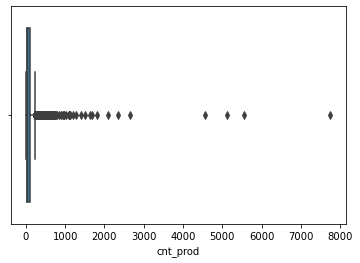

In [6]:
sns.boxplot(customer_df.cnt_prod)

특정 이상치를 보이는 손님들이 존재한다. 절대 평가로 하기에는 많은 유저들은 몰려있어, 어느 정도 유저의 % 단위로 나눠서 판단하는 것이 더 좋을 수도 있다.

C:\Users\USER\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='cnt_pay'>

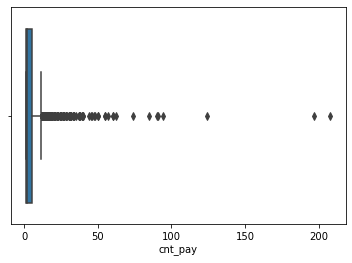

In [7]:
sns.boxplot(customer_df.cnt_pay)

결제 횟수 단위로도 마찬가지이고

C:\Users\USER\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='cnt_quant'>

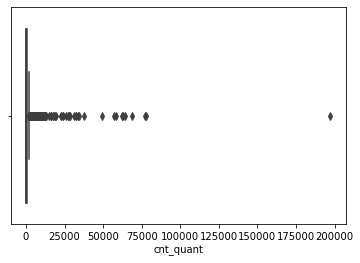

In [8]:
sns.boxplot(customer_df.cnt_quant)

전체 수량으로 봐도 마찬가지이고

C:\Users\USER\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='total_rev'>

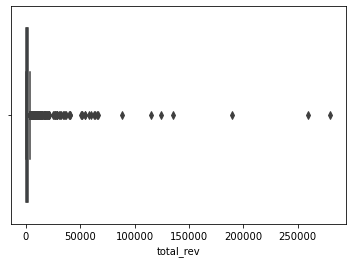

In [9]:
sns.boxplot(customer_df.total_rev)

구매 금액으로 봐도 마찬가지이다.

따라서, 절대값으로 자르기보다는 분위수를 잘 활용하는 것이 좋을 것이다.
전략은 하위부터 나누어, 다음과 같이 분배할려고 한다.
- D : 하위 25%
- C : 25~50%
- B : 50~75%
- A : 75~99%
- S : 상위 1%

5개의 등급으로 나누려고 한다.

In [14]:
customer_df

,id,cnt_prod,cnt_pay,cnt_quant,total_rev,last_buy_date
0,12347,182,7,2458,4310.00,2011-12-07
1,12348,31,4,2341,1797.24,2011-09-25
2,12349,73,1,631,1757.55,2011-11-21
3,12350,17,1,197,334.40,2011-02-02
4,12352,77,8,472,2009.21,2011-11-03
...,...,...,...,...,...,...
4321,18280,10,1,45,180.60,2011-03-07
4322,18281,7,1,54,80.82,2011-06-12
4323,18282,12,2,103,178.05,2011-12-02
4324,18283,756,16,1397,2094.88,2011-12-06


In [10]:
np.percentile(customer_df['cnt_prod'], [25, 50, 75, 99], interpolation='higher')

array([ 17,  41,  99, 662], dtype=int64)

즉 0에서 16이면 D, 17에서 40은 C, 41에서 98은 B, 99에서 661은 A, 662부터는 S이다.

In [11]:
def get_grade_prod(x, q):
    if x < q[0]: return 'D'
    elif x < q[1]: return 'C'
    elif x < q[2]: return 'B'
    elif x < q[3] : return 'A'
    else: return 'S'
    
q_prod = np.percentile(customer_df['cnt_prod'], [25, 50, 75, 99], interpolation='higher')
q_pay = np.percentile(customer_df['cnt_pay'], [25, 50, 75, 99], interpolation='higher')
q_quant = np.percentile(customer_df['cnt_quant'], [25, 50, 75, 99], interpolation='higher')
q_rev = np.percentile(customer_df['total_rev'], [25, 50, 75, 99], interpolation='higher')

customer_df['cnt_prod_grade'] = customer_df.cnt_prod.apply(lambda x : get_grade_prod(x, q_prod))
customer_df['cnt_pay_grade'] = customer_df.cnt_pay.apply(lambda x : get_grade_prod(x, q_pay)) 
customer_df['cnt_quant_grade'] = customer_df.cnt_quant.apply(lambda x : get_grade_prod(x, q_quant)) 
customer_df['total_rev_grade'] = customer_df.total_rev.apply(lambda x : get_grade_prod(x, q_rev)) 

In [20]:
customer_df

,id,cnt_prod,cnt_pay,cnt_quant,total_rev,last_buy_date,cnt_prod_grade,cnt_pay_grade,cnt_quant_grade,total_rev_grade
0,12347,182,7,2458,4310.00,2011-12-07,A,A,A,A
1,12348,31,4,2341,1797.24,2011-09-25,C,B,A,A
2,12349,73,1,631,1757.55,2011-11-21,B,C,B,A
3,12350,17,1,197,334.40,2011-02-02,C,C,C,C
4,12352,77,8,472,2009.21,2011-11-03,B,A,B,A
...,...,...,...,...,...,...,...,...,...,...
4321,18280,10,1,45,180.60,2011-03-07,D,C,D,D
4322,18281,7,1,54,80.82,2011-06-12,D,C,D,D
4323,18282,12,2,103,178.05,2011-12-02,D,B,D,D
4324,18283,756,16,1397,2094.88,2011-12-06,S,A,A,A


다음은 last_buy_date에 대한 작업이다.

In [12]:
print(max(customer_df['last_buy_date']))
print(min(customer_df['last_buy_date']))

2011-12-09
2010-12-01


2010.12.01 ~ 2011.12.9로 구성되어 있다. 따라서 다음과 같이 구성하면 좋을 것이다.
다만, 이것은 위의처럼 더 많이 구매 이런거보다는 구매 시점 자체이므로 상대평가보다는 절대평가가 적합하다.
- D : 나머지
- C : 180일 전까지
- B : 90일 전까지
- A : 30일 전까지
- S : 7일 전까지

이를 위해서는 날짜 차이 계산이 필요하다.

In [13]:
from datetime import datetime
standard = datetime.strptime("2011-12-09", '%Y-%m-%d')
customer_df['date_diff'] = customer_df.last_buy_date.apply(lambda x : (standard-datetime.strptime(x, '%Y-%m-%d')).days)

In [14]:
customer_df

,id,cnt_prod,cnt_pay,cnt_quant,total_rev,last_buy_date,cnt_prod_grade,cnt_pay_grade,cnt_quant_grade,total_rev_grade,date_diff
0,12347,182,7,2458,4310.00,2011-12-07,A,A,A,A,2
1,12348,31,4,2341,1797.24,2011-09-25,C,B,A,A,75
2,12349,73,1,631,1757.55,2011-11-21,B,C,B,A,18
3,12350,17,1,197,334.40,2011-02-02,C,C,C,C,310
4,12352,77,8,472,2009.21,2011-11-03,B,A,B,A,36
...,...,...,...,...,...,...,...,...,...,...,...
4321,18280,10,1,45,180.60,2011-03-07,D,C,D,D,277
4322,18281,7,1,54,80.82,2011-06-12,D,C,D,D,180
4323,18282,12,2,103,178.05,2011-12-02,D,B,D,D,7
4324,18283,756,16,1397,2094.88,2011-12-06,S,A,A,A,3


다음과 같이 날짜 차이를 구할 수 있다. 이제 등급을 매기자

In [15]:
def get_grade_date(x):
    if x > 180: return 'D'
    elif x > 90: return 'C'
    elif x > 30: return 'B'
    elif x > 7 : return 'A'
    else: return 'S'
customer_df['date_diff_grade'] = customer_df.date_diff.apply(lambda x : get_grade_date(x))

In [16]:
customer_df

,id,cnt_prod,cnt_pay,cnt_quant,total_rev,last_buy_date,cnt_prod_grade,cnt_pay_grade,cnt_quant_grade,total_rev_grade,date_diff,date_diff_grade
0,12347,182,7,2458,4310.00,2011-12-07,A,A,A,A,2,S
1,12348,31,4,2341,1797.24,2011-09-25,C,B,A,A,75,B
2,12349,73,1,631,1757.55,2011-11-21,B,C,B,A,18,A
3,12350,17,1,197,334.40,2011-02-02,C,C,C,C,310,D
4,12352,77,8,472,2009.21,2011-11-03,B,A,B,A,36,B
...,...,...,...,...,...,...,...,...,...,...,...,...
4321,18280,10,1,45,180.60,2011-03-07,D,C,D,D,277,D
4322,18281,7,1,54,80.82,2011-06-12,D,C,D,D,180,C
4323,18282,12,2,103,178.05,2011-12-02,D,B,D,D,7,S
4324,18283,756,16,1397,2094.88,2011-12-06,S,A,A,A,3,S


이제 F, R, M 요소별로 최종 등급 테이블만을 가져오자

In [17]:
customer_rank_df = customer_df[['id', 'date_diff_grade', 'cnt_prod_grade', 'cnt_pay_grade', 'cnt_quant_grade', 'total_rev_grade']]

In [18]:
customer_rank_df

,id,date_diff_grade,cnt_prod_grade,cnt_pay_grade,cnt_quant_grade,total_rev_grade
0,12347,S,A,A,A,A
1,12348,B,C,B,A,A
2,12349,A,B,C,B,A
3,12350,D,C,C,C,C
4,12352,B,B,A,B,A
...,...,...,...,...,...,...
4321,18280,D,D,C,D,D
4322,18281,C,D,C,D,D
4323,18282,S,D,B,D,D
4324,18283,S,S,A,A,A


해당 데이터를 비중으로 다양한 캠페인 대상을 결정할 수 있을 것이다.

## Case 1 > 매출액은 매우 높았는데, 떠나간 유저

매출액은 S 랭크이나, 6개월 이상 떠나가버린 유저를 분석해보자

In [38]:
customer_rank_df.loc[(customer_rank_df.total_rev_grade == 'S') & (customer_rank_df.date_diff_grade == 'D')]

,id,date_diff_grade,cnt_prod_grade,cnt_pay_grade,cnt_quant_grade,total_rev_grade
2004,15098,D,D,B,D,S
2495,15749,D,D,B,S,S


다음 두 명의 유저가 결정되어 분석 대상으로 볼 수 있을 것이다.

In [41]:
df.loc[df.CustomerID == 15098]

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
222670,222670,556442,22502,PICNIC BASKET WICKER SMALL,60,6/10/2011 15:22,4.95,15098.0,United Kingdom
222680,222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,6/10/2011 15:28,649.50,15098.0,United Kingdom
222681,222681,C556445,M,Manual,-1,6/10/2011 15:31,38970.00,15098.0,United Kingdom
222682,222682,556446,22502,PICNIC BASKET WICKER 60 PIECES,1,6/10/2011 15:33,649.50,15098.0,United Kingdom
222692,222692,C556448,22502,PICNIC BASKET WICKER SMALL,-60,6/10/2011 15:39,4.95,15098.0,United Kingdom


이 유저의 경우는, Manual이라는 것이 있는 것으로 보아 무언가 환불이 이루어진 유저로 생각할 수 있을 것이다.
rev가 높게 잡힌 이유는 Manual에 의한 환불, 즉 그냥 이 분은 아예 전처리에서도 예외로 잡혀버린 불만 고객이다.

In [42]:
df.loc[df.CustomerID == 15749]

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
52709,52709,540815,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930,1/11/2011 12:55,2.55,15749.0,United Kingdom
52710,52710,540815,21175,GIN + TONIC DIET METAL SIGN,2000,1/11/2011 12:55,1.85,15749.0,United Kingdom
52711,52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,1/11/2011 12:55,2.10,15749.0,United Kingdom
52771,52771,540818,47556B,TEA TIME TEA TOWELS,1300,1/11/2011 12:57,2.55,15749.0,United Kingdom
52772,52772,540818,48185,DOORMAT FAIRY CAKE,670,1/11/2011 12:57,6.75,15749.0,United Kingdom
160141,160141,C550456,48185,DOORMAT FAIRY CAKE,-670,4/18/2011 13:08,6.75,15749.0,United Kingdom
160142,160142,C550456,47566B,TEA TIME PARTY BUNTING,-1300,4/18/2011 13:08,2.55,15749.0,United Kingdom
160143,160143,C550456,85123A,WHITE HANGING HEART T-LIGHT HOLDER,-1930,4/18/2011 13:08,2.55,15749.0,United Kingdom
160144,160144,C550456,21175,GIN + TONIC DIET METAL SIGN,-2000,4/18/2011 13:08,1.85,15749.0,United Kingdom
160145,160145,C550456,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,-3114,4/18/2011 13:08,2.10,15749.0,United Kingdom


환불 경험이 세트로 크게 한번 있다.

In [44]:
customer_rank_df.loc[(customer_rank_df.total_rev_grade == 'S') & (customer_rank_df.date_diff_grade == 'B')]

,id,date_diff_grade,cnt_prod_grade,cnt_pay_grade,cnt_quant_grade,total_rev_grade
320,12744,B,A,A,A,S
2694,16029,B,A,S,S,S


최근 구매 기간 등급이 C는 없고 B인 유저는  존재한다. 이 고객들도 한번 보자

In [46]:
df.loc[df.CustomerID == 12744]

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
70758,70758,542102,21519,GIN & TONIC DIET GREETING CARD,72,1/25/2011 13:26,0.36,12744.0,Singapore
70759,70759,542102,22697,GREEN REGENCY TEACUP AND SAUCER,6,1/25/2011 13:26,2.95,12744.0,Singapore
70760,70760,542102,22699,ROSES REGENCY TEACUP AND SAUCER,6,1/25/2011 13:26,2.95,12744.0,Singapore
70761,70761,542102,22343,PARTY PIZZA DISH RED RETROSPOT,24,1/25/2011 13:26,0.21,12744.0,Singapore
70762,70762,542102,22344,PARTY PIZZA DISH PINK POLKADOT,24,1/25/2011 13:26,0.21,12744.0,Singapore
...,...,...,...,...,...,...,...,...,...
398370,398370,571239,21888,BINGO SET,12,10/14/2011 14:54,3.75,12744.0,Singapore
406404,406404,C571750,M,Manual,-1,10/19/2011 11:16,3949.32,12744.0,Singapore
406405,406405,C571750,M,Manual,-1,10/19/2011 11:16,2118.74,12744.0,Singapore
406406,406406,571751,M,Manual,1,10/19/2011 11:18,3949.32,12744.0,Singapore


환불이 어느 정도 존재하지만 기존에 상대적으로 많이 구매를 한 유저이다.

In [47]:
df.loc[df.CustomerID == 16029]

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
175,175,536386,84880,WHITE WIRE EGG HOLDER,36,12/1/2010 9:57,4.95,16029.0,United Kingdom
176,176,536386,85099C,JUMBO BAG BAROQUE BLACK WHITE,100,12/1/2010 9:57,1.65,16029.0,United Kingdom
177,177,536386,85099B,JUMBO BAG RED RETROSPOT,100,12/1/2010 9:57,1.65,16029.0,United Kingdom
178,178,536387,79321,CHILLI LIGHTS,192,12/1/2010 9:58,3.82,16029.0,United Kingdom
179,179,536387,22780,LIGHT GARLAND BUTTERFILES PINK,192,12/1/2010 9:58,3.37,16029.0,United Kingdom
...,...,...,...,...,...,...,...,...,...
431946,431946,573774,22666,RECIPE BOX PANTRY YELLOW DESIGN,36,11/1/2011 10:27,2.55,16029.0,United Kingdom
431947,431947,573774,23206,LUNCH BAG APPLE DESIGN,50,11/1/2011 10:27,1.45,16029.0,United Kingdom
431948,431948,573774,22961,JAM MAKING SET PRINTED,96,11/1/2011 10:27,1.25,16029.0,United Kingdom
431949,431949,573774,21931,JUMBO STORAGE BAG SUKI,100,11/1/2011 10:27,1.74,16029.0,United Kingdom


In [48]:
customer_rank_df.loc[(customer_rank_df.total_rev_grade == 'A') & (customer_rank_df.date_diff_grade == 'D')]

,id,date_diff_grade,cnt_prod_grade,cnt_pay_grade,cnt_quant_grade,total_rev_grade
30,12383,D,A,A,A,A
121,12501,D,A,C,A,A
188,12585,D,B,B,A,A
193,12590,D,B,B,A,A
223,12625,D,B,B,A,A
327,12754,D,B,B,A,A
328,12755,D,D,B,A,A
335,12764,D,B,C,B,A
562,13093,D,A,A,A,A
593,13135,D,D,C,A,A


구매 금액 등급이 A인  이상중 이탈 유저 또한 많이 존재한다. 이 고객들의 세부 리스트를 분석하여, 떠나간 VIP 고객들에 대한 캠페인을 
방법으로 진행할 수 있을 것이다. -> 매출 향상 자체에 기대

## Case 2 > 이제 막 구매를 시작한 신규 유저

이제 막 구매를 한 유저들의 충성도를 올리기에 적합할 것이기에 우선 가장 최근 구매 유저들을 살펴본다.

In [49]:
customer_rank_df.loc[(customer_rank_df.date_diff_grade == 'S')]

,id,date_diff_grade,cnt_prod_grade,cnt_pay_grade,cnt_quant_grade,total_rev_grade
0,12347,S,A,A,A,A
10,12358,S,C,B,C,B
14,12362,S,A,A,A,A
16,12364,S,B,B,A,B
18,12367,S,D,C,C,D
...,...,...,...,...,...,...
4299,18245,S,A,A,A,A
4316,18272,S,A,A,A,A
4317,18273,S,D,B,D,D
4323,18282,S,D,B,D,D


약 500명 정도의 유저들이 분포해있는데, 이들 중 이미 구매 금액이나 구매 수량이 많은 VIP에 가까운 유저들도 존재한다.
이들을 대상으로 구매하는 상품 관련하여 새로운 상품 마케팅 등 또한 실시 가능할 것이다.

### So What?

이 등급 데이터 자체로만 놓고 보면 고객의 분류 이상을 진행시키기는 솔직히 어려워 보인다. 물론 매출 기여도를 파악하여 우리 고객이 어떤 고객이다. 등을 알 수 있을 것이다...만...

오히려, 특정 문제를 풀기 위해 필요한 고객군을 선정하는 데에 도움이 될 수 있을 것이라 생각된다.